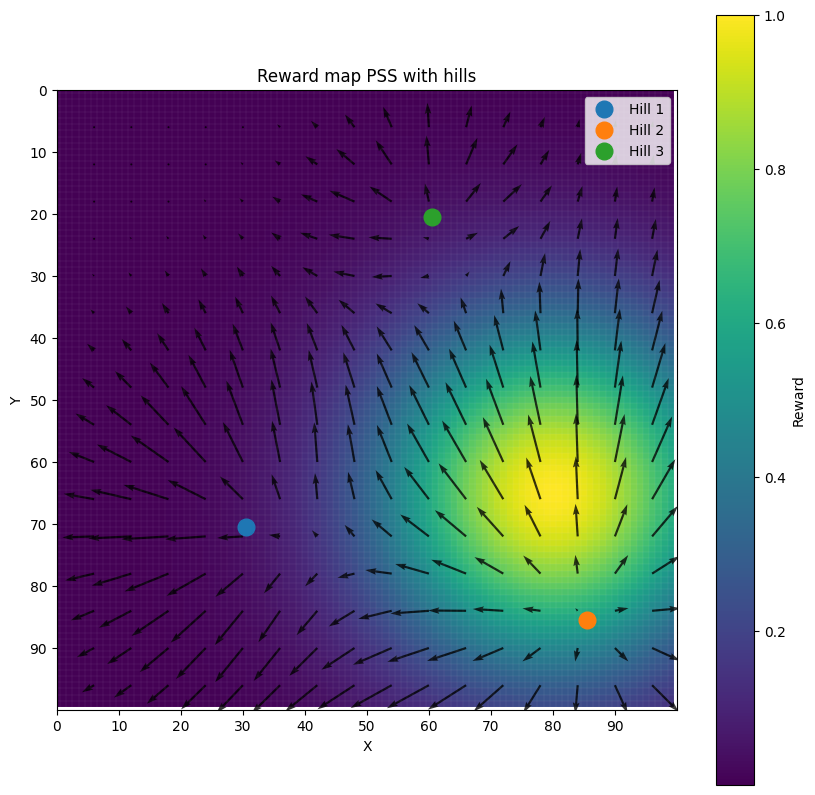

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import sys
import numpy as np


# Ensure project root (parent of notebooks/) is on PYTHONPATH
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import directly from module (not from src/__init__.py)
from src.environment_2 import ProbabilisticSimpleSystem

env = ProbabilisticSimpleSystem(seed=64)
env.clear_hills()
env.add_hill(top=(30, 70), sigma=15.0, strength=35, normalized=False)
env.add_hill(top=(85, 85), sigma=30.0, strength=100, normalized=False)
env.add_hill(top=(60, 20), sigma = 10, strength=15.0, normalized=False)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
env.plot_reward_map(ax=ax)
env.plot_hills(ax=ax)
ax.set_title("Reward map PSS with hills")
plt.show()

In [2]:
import math
import torch
import gpytorch
import botorch
from matplotlib import pyplot as plt
import random

actions = {
    'up': (0, -1),
    'right': (1, 0),
    'down': (0, 1),
    'left': (-1, 0),
}

start_state = (50, 50)

/Users/thijsvanschaik/Desktop/school/Uni/year4_last_hopefully/thesis_yehes/starting_fr_fr/BayesianRLunderUncertainty/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Generate training data
walk_length = 500
actions_taken = [random.choice(list(actions.values())) for _ in range(walk_length)]
state = start_state
start_positions = [(50, 50), (20, 20), (80, 80), (20, 80), (80, 20)]

# N samples x M tasks, (0,4) as we have not sampled yet
train_x = torch.empty((0, 4), dtype=torch.float64)
train_y = torch.empty((0, 2), dtype=torch.float64)

states_visited = []

for start_pos in start_positions:
    state = start_pos
    for i in range(walk_length):
        x, y = state
        states_visited.append(state)
        state = env.transition(state=state, action=actions_taken[i])
        train_x = torch.cat((train_x, torch.tensor([[x, y, actions_taken[i][0], actions_taken[i][1]]], dtype=torch.float64)), dim=0)
        train_y = torch.cat((train_y, torch.tensor([[state[0], state[1]]], dtype=torch.float64)), dim=0)

# for i in range(walk_length):
#     x, y = state
#     state = env.transition(state=start_state, action=actions_taken[i])
#     train_x = torch.cat((train_x, torch.tensor([[start_state[0], start_state[1], actions_taken[i][0], actions_taken[i][1]]])), dim=0)
#     train_y = torch.cat((train_y, torch.tensor([[state[0], state[1]]])), dim=0)

print(train_x.shape)
print(train_y.shape)

states_visited = {x: states_visited.count(x) for x in states_visited}

torch.Size([2500, 4])
torch.Size([2500, 2])


In [4]:
from botorch.models import SingleTaskGP
from botorch.models.transforms.input import Normalize
from botorch.models.transforms.outcome import Standardize

class BoTorchDualSingleTaskGP:
    def __init__(self, train_x, train_y, normalize_inputs=True, standardize_outputs=True, 
                 x_kernel=gpytorch.kernels.RBFKernel, y_kernel=gpytorch.kernels.RBFKernel):
        train_x = train_x.to(torch.float64)
        train_y = train_y.to(torch.float64)
        
        self.num_tasks = 2
        n_inputs = train_x.shape[-1]
        
        # Store training data
        self.train_x = train_x
        self.train_y = train_y

        # Inputs are: x_pos (0-100), y_pos (0-100), action_x (-1 to 1), action_y (-1 to 1)
        bounds = torch.tensor([
            [0., 0., -1., -1.],
            [100., 100., 1., 1.]
        ], dtype=torch.float64)
        
        # Create two independent SingleTaskGPs with built-in normalization
        self.gp_x = SingleTaskGP(
            train_X=train_x,
            train_Y=train_y[:, 0:1],
            input_transform=Normalize(d=n_inputs, bounds=bounds) if normalize_inputs else None,
            outcome_transform=Standardize(m=1) if standardize_outputs else None,
            covar_module=x_kernel()
        )
        
        self.gp_y = SingleTaskGP(
            train_X=train_x,
            train_Y=train_y[:, 1:2],
            input_transform=Normalize(d=n_inputs, bounds=bounds) if normalize_inputs else None,
            outcome_transform=Standardize(m=1) if standardize_outputs else None,
            covar_module=y_kernel()
        )
        
        # Create MLLs for each GP
        self.mll_x = gpytorch.mlls.ExactMarginalLogLikelihood(self.gp_x.likelihood, self.gp_x)
        self.mll_y = gpytorch.mlls.ExactMarginalLogLikelihood(self.gp_y.likelihood, self.gp_y)
    
    def fit(self, training_iterations=50, lr=0.1, verbose=True):
        """Train both GPs independently."""
        self.gp_x.train()
        self.gp_y.train()
        
        optimizer_x = torch.optim.Adam(self.gp_x.parameters(), lr=lr)
        optimizer_y = torch.optim.Adam(self.gp_y.parameters(), lr=lr)
        
        losses_x = []
        losses_y = []
        
        for i in range(training_iterations):
            # Train GP for x-coordinate
            optimizer_x.zero_grad()
            output_x = self.gp_x(self.train_x)
            loss_x = -self.mll_x(output_x, self.train_y[:, 0])
            loss_x.backward()
            optimizer_x.step()
            losses_x.append(loss_x.item())
            
            # Train GP for y-coordinate
            optimizer_y.zero_grad()
            output_y = self.gp_y(self.train_x)
            loss_y = -self.mll_y(output_y, self.train_y[:, 1])
            loss_y.backward()
            optimizer_y.step()
            losses_y.append(loss_y.item())
            
            if verbose and (i + 1) % 10 == 0:
                print(f'Iter {i+1}/{training_iterations} - Loss X: {loss_x.item():.3f}, Loss Y: {loss_y.item():.3f}')
        
        return losses_x, losses_y
    
    def predict(self, x):
        """
        Get prediction at x. Returns mean and covariance in raw space.
        Only combines outputs here at prediction time.
        """
        x = x.to(torch.float64)
        
        self.gp_x.eval()
        self.gp_y.eval()
        
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            # Get posterior from each GP (already untransformed by BoTorch)
            posterior_x = self.gp_x.posterior(x)
            posterior_y = self.gp_y.posterior(x)
            
            # Means: (n, 1) each -> stack to (n, 2)
            mean_x = posterior_x.mean.squeeze(-1)  # (n,)
            mean_y = posterior_y.mean.squeeze(-1)  # (n,)
            mean = torch.stack([mean_x, mean_y], dim=-1)  # (n, 2)
            
            # Variances: (n, 1, 1) each -> extract diagonal
            var_x = posterior_x.variance.squeeze(-1)  # (n,)
            var_y = posterior_y.variance.squeeze(-1)  # (n,)
            
            # Build 2x2 covariance per point (independent outputs -> diagonal)
            # For single point: just return 2x2 diagonal covariance
            if x.shape[0] == 1:
                cov = torch.diag(torch.stack([var_x.squeeze(), var_y.squeeze()]))
            else:
                # For multiple points, return per-point 2x2 covariances
                cov = torch.zeros(x.shape[0], 2, 2, dtype=x.dtype)
                cov[:, 0, 0] = var_x
                cov[:, 1, 1] = var_y
        
        return mean, cov
    
    def eval(self):
        """Set both GPs to eval mode."""
        self.gp_x.eval()
        self.gp_y.eval()
        return self


# Create model
model = BoTorchDualSingleTaskGP(train_x, train_y)

Iter 10/50 - Loss X: 4.826, Loss Y: 6.714
Iter 20/50 - Loss X: 4.516, Loss Y: 6.152
Iter 30/50 - Loss X: 4.420, Loss Y: 5.906
Iter 40/50 - Loss X: 4.367, Loss Y: 5.839
Iter 50/50 - Loss X: 4.325, Loss Y: 5.766


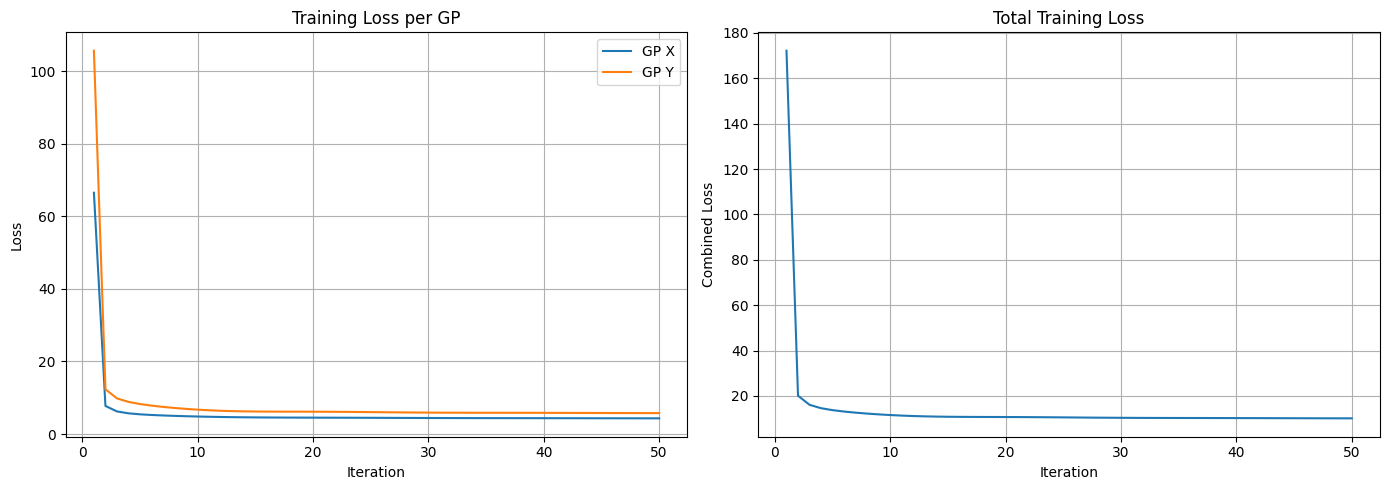

In [5]:
# Train both GPs
losses_x, losses_y = model.fit(training_iterations=50, lr=0.1, verbose=True)

# Plot loss curves
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].plot(range(1, len(losses_x) + 1), losses_x, label='GP X')
axs[0].plot(range(1, len(losses_y) + 1), losses_y, label='GP Y')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel('Loss')
axs[0].set_title('Training Loss per GP')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(range(1, len(losses_x) + 1), [lx + ly for lx, ly in zip(losses_x, losses_y)])
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Combined Loss')
axs[1].set_title('Total Training Loss')
axs[1].grid(True)

plt.tight_layout()
plt.show()

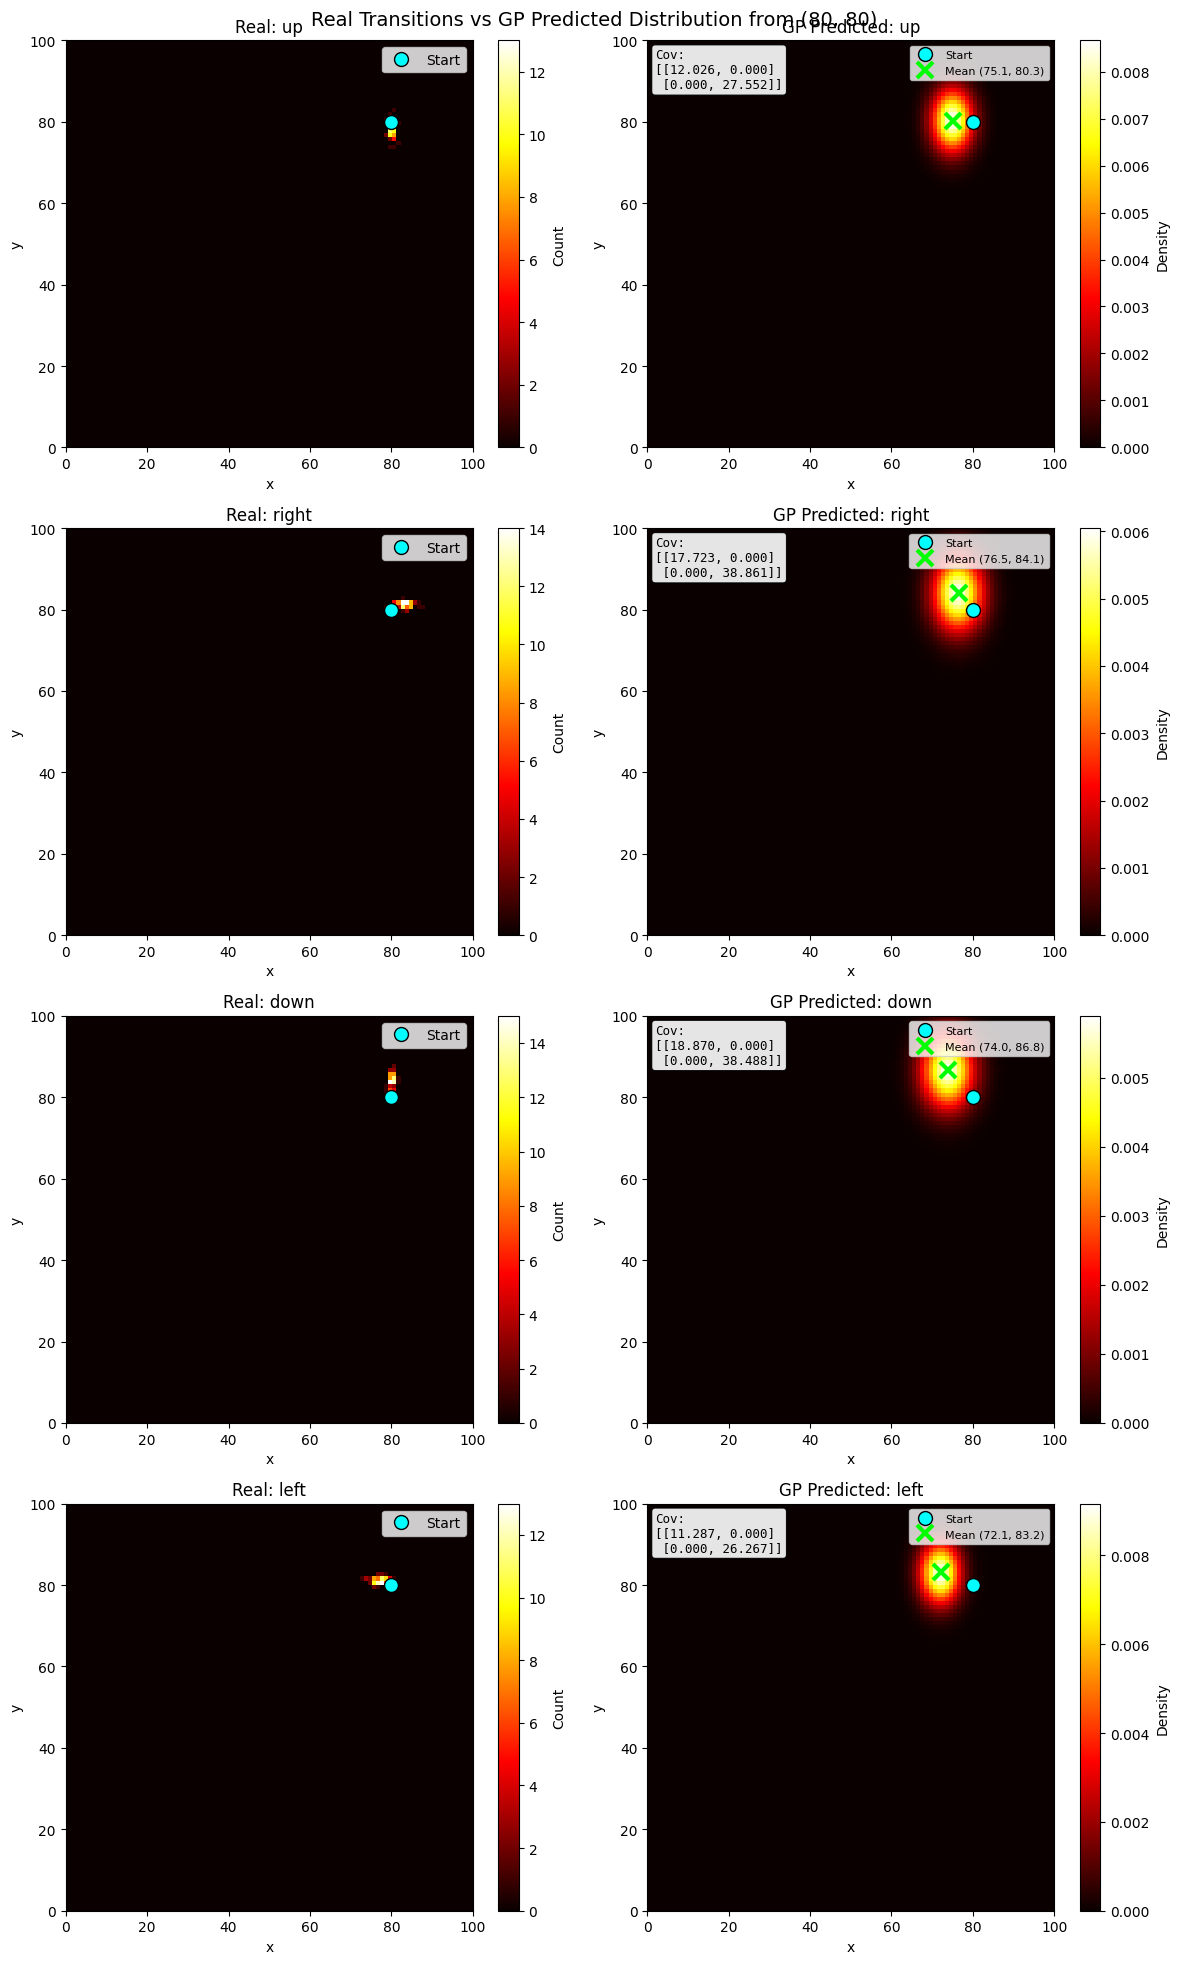

In [6]:
# Compare GP predicted distribution vs real transition distribution
from scipy.stats import multivariate_normal

start_state = (80, 80)
n_samples = 100

fig, axs = plt.subplots(4, 2, figsize=(12, 20))

for row, (action_name, action) in enumerate(actions.items()):
    ax_real = axs[row, 0]
    ax_gp = axs[row, 1]
    
    # Build input for GP
    x_input = torch.tensor([[start_state[0], start_state[1], action[0], action[1]]], dtype=torch.float64)
    
    # Get GP prediction using new predict method
    pred_mean, pred_cov = model.predict(x_input)
    pred_mean = pred_mean.squeeze().numpy()  # (2,)
    pred_cov = pred_cov.numpy()  # (2, 2)
    
    # Sample from real environment
    counts_real = np.zeros((100, 100))
    for _ in range(n_samples):
        x, y = env.transition(start_state, action)
        counts_real[y, x] += 1
    
    x0, y0 = start_state
    
    # Plot real heatmap
    im_real = ax_real.imshow(counts_real, cmap='hot', origin='lower',
                              extent=[0, 100, 0, 100])
    ax_real.plot(x0, y0, 'o', markersize=10, label='Start', color='cyan', markeredgecolor='black')
    ax_real.set_title(f"Real: {action_name}")
    ax_real.set_xlabel('x')
    ax_real.set_ylabel('y')
    ax_real.legend()
    plt.colorbar(im_real, ax=ax_real, label='Count')
    
    # Create 2D Gaussian density from GP prediction
    # Ensure positive definite
    eigenvalues, eigenvectors = np.linalg.eigh(pred_cov)
    eigenvalues = np.abs(eigenvalues) + 1e-6
    pred_cov_fixed = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    
    # Create grid for density evaluation
    x_grid = np.linspace(0, 100, 100)
    y_grid = np.linspace(0, 100, 100)
    X, Y = np.meshgrid(x_grid, y_grid)
    pos = np.dstack((X, Y))
    
    # Evaluate 2D Gaussian PDF
    rv = multivariate_normal(pred_mean, pred_cov_fixed)
    Z = rv.pdf(pos)
    
    # Plot GP density as heatmap
    im_gp = ax_gp.imshow(Z, cmap='hot', origin='lower', extent=[0, 100, 0, 100])
    ax_gp.plot(x0, y0, 'o', markersize=10, label='Start', color='cyan', markeredgecolor='black')
    ax_gp.plot(pred_mean[0], pred_mean[1], 'x', markersize=12, color='lime', 
               markeredgewidth=3, label=f'Mean ({pred_mean[0]:.1f}, {pred_mean[1]:.1f})')
    
    ax_gp.set_title(f"GP Predicted: {action_name}")
    ax_gp.set_xlabel('x')
    ax_gp.set_ylabel('y')
    ax_gp.legend(loc='upper right', fontsize=8)
    plt.colorbar(im_gp, ax=ax_gp, label='Density')
    
    # Add covariance matrix text
    cov_text = f"Cov:\n[[{pred_cov[0,0]:.3f}, {pred_cov[0,1]:.3f}]\n [{pred_cov[1,0]:.3f}, {pred_cov[1,1]:.3f}]]"
    ax_gp.text(0.02, 0.98, cov_text,
               transform=ax_gp.transAxes, fontsize=9, verticalalignment='top',
               horizontalalignment='left', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))

plt.suptitle(f'Real Transitions vs GP Predicted Distribution from {start_state}', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
# takes very long
def plot_ll_heatmap(model, 
                    start_positions, 
                    env, 
                    actions, 
                    grid_resolution=100, 
                    n_samples_per_cell=50, 
                    threshold=-10,
                    red_max=-2,
                    ax=None
                    ):
    """
    Plot log-likelihood heatmap for BoTorchDualSingleTaskGP model.
    Uses model.predict() to get mean and covariance.
    """
    from matplotlib.colors import LinearSegmentedColormap

    x_coords = np.linspace(0, 99, grid_resolution)
    y_coords = np.linspace(0, 99, grid_resolution)

    log_likelihood_map = np.zeros((grid_resolution, grid_resolution))

    model.eval()

    for i, x in enumerate(x_coords):
        for j, y in enumerate(y_coords):
            state = (int(x), int(y))
            total_log_prob = 0
            
            for action_name, action in actions.items():
                # Get GP prediction using new predict method
                x_input = torch.tensor([[state[0], state[1], action[0], action[1]]], dtype=torch.float64)
                pred_mean, pred_cov = model.predict(x_input)
                pred_mean = pred_mean.squeeze()  # (2,)
                pred_cov = pred_cov  # (2, 2)
                
                # Sample from real environment and compute log prob under GP
                for _ in range(n_samples_per_cell):
                    next_state = env.transition(state, action)
                    next_state_tensor = torch.tensor([next_state[0], next_state[1]], dtype=torch.float64)
                    
                    # Create distribution and compute log prob
                    try:
                        dist = torch.distributions.MultivariateNormal(pred_mean, pred_cov)
                        log_prob = dist.log_prob(next_state_tensor).item()
                    except:
                        # If covariance is not positive definite, use diagonal approximation
                        log_prob = -10  # penalty for numerical issues
                    
                    total_log_prob += log_prob
            
            # Average log likelihood for this cell
            log_likelihood_map[j, i] = total_log_prob / (len(actions) * n_samples_per_cell)
        
        if (i + 1) % 10 == 0:
            print(f"Processed row {i+1}/{grid_resolution}")

    # Create custom colormap: viridis for values <= threshold, red gradient for > threshold
    vmin, vmax = log_likelihood_map.min(), log_likelihood_map.max()

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Plot main heatmap with viridis for values below threshold
    plot_data_viridis = np.where(log_likelihood_map <= threshold, log_likelihood_map, np.nan)
    im = ax.imshow(plot_data_viridis, cmap='viridis', origin='lower', 
                extent=[0, 100, 0, 100], aspect='equal', vmin=vmin, vmax=threshold)

    # Create red gradient colormap (light red to dark red)
    reds_cmap = LinearSegmentedColormap.from_list('custom_reds', ['#ffcccc', '#ff0000', '#8b0000'])

    # Plot red gradient for values > threshold
    plot_data_red = np.where(log_likelihood_map > threshold, log_likelihood_map, np.nan)
    im_red = ax.imshow(plot_data_red, cmap=reds_cmap, origin='lower', 
                    extent=[0, 100, 0, 100], aspect='equal', vmin=threshold, vmax=red_max)

    # Add colorbars
    plt.colorbar(im, ax=ax, label='Log Likelihood (poor)', location='left', pad=0.12)
    plt.colorbar(im_red, ax=ax, label='Log Likelihood (good)', location='right')

    # Mark training start positions
    for pos in start_positions:
        ax.plot(pos[0], pos[1], 'w*', markersize=15, markeredgecolor='black', markeredgewidth=1)

    env.plot_hills(ax=ax)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'GP Model Log Likelihood Heatmap\n(White stars = training start positions)')

    good_mask = log_likelihood_map > threshold
    print(f"\nLog likelihood statistics:")
    print(f"  Min: {log_likelihood_map.min():.2f}")
    print(f"  Max: {log_likelihood_map.max():.2f}")
    print(f"  Mean: {log_likelihood_map.mean():.2f}")
    print(f"  Cells with LL > {threshold}: {good_mask.sum()} / {log_likelihood_map.size}")
    
    return ax, log_likelihood_map


def plot_ll_heatmap_simple(model, 
                           start_positions, 
                           env, 
                           actions, 
                           grid_resolution=100, 
                           n_samples_per_cell=50, 
                           cmap='RdYlGn',
                           vmin=None,
                           vmax=None,
                           ax=None,
                           show_hills=True,
                           show_start_positions=True,
                           colorbar_label='Log Likelihood'
                           ):
    """
    Simple log-likelihood heatmap with single colormap and adjustable colors.
    
    Args:
        model: BoTorchDualSingleTaskGP model
        start_positions: list of (x, y) training start positions
        env: environment for sampling transitions
        actions: dict of action name -> action tuple
        grid_resolution: number of grid cells per axis
        n_samples_per_cell: samples per cell for LL estimation
        cmap: colormap name or LinearSegmentedColormap (e.g. 'viridis', 'RdYlGn', 'coolwarm')
        vmin: minimum value for colormap (None = auto)
        vmax: maximum value for colormap (None = auto)
        ax: matplotlib axes (creates new if None)
        show_hills: whether to overlay hill contours
        show_start_positions: whether to mark training start positions
        colorbar_label: label for the colorbar
    
    Returns:
        ax, log_likelihood_map
    """
    from matplotlib.colors import LinearSegmentedColormap

    x_coords = np.linspace(0, 99, grid_resolution)
    y_coords = np.linspace(0, 99, grid_resolution)

    log_likelihood_map = np.zeros((grid_resolution, grid_resolution))

    model.eval()

    for i, x in enumerate(x_coords):
        for j, y in enumerate(y_coords):
            state = (int(x), int(y))
            total_log_prob = 0
            
            for action_name, action in actions.items():
                x_input = torch.tensor([[state[0], state[1], action[0], action[1]]], dtype=torch.float64)
                pred_mean, pred_cov = model.predict(x_input)
                pred_mean = pred_mean.squeeze()
                
                for _ in range(n_samples_per_cell):
                    next_state = env.transition(state, action)
                    next_state_tensor = torch.tensor([next_state[0], next_state[1]], dtype=torch.float64)
                    
                    try:
                        dist = torch.distributions.MultivariateNormal(pred_mean, pred_cov)
                        log_prob = dist.log_prob(next_state_tensor).item()
                    except:
                        log_prob = -10
                    
                    total_log_prob += log_prob
            
            log_likelihood_map[j, i] = total_log_prob / (len(actions) * n_samples_per_cell)
        
        if (i + 1) % 10 == 0:
            print(f"Processed row {i+1}/{grid_resolution}")

    # Use provided bounds or auto-detect
    plot_vmin = vmin if vmin is not None else log_likelihood_map.min()
    plot_vmax = vmax if vmax is not None else log_likelihood_map.max()

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Single colormap for entire range
    im = ax.imshow(log_likelihood_map, cmap=cmap, origin='lower', 
                   extent=[0, 100, 0, 100], aspect='equal', 
                   vmin=plot_vmin, vmax=plot_vmax)

    plt.colorbar(im, ax=ax, label=colorbar_label)

    if show_start_positions:
        for pos in start_positions:
            ax.plot(pos[0], pos[1], 'w*', markersize=15, markeredgecolor='black', markeredgewidth=1)

    if show_hills:
        env.plot_hills(ax=ax)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('GP Model Log Likelihood Heatmap')

    print(f"\nLog likelihood statistics:")
    print(f"  Min: {log_likelihood_map.min():.2f}")
    print(f"  Max: {log_likelihood_map.max():.2f}")
    print(f"  Mean: {log_likelihood_map.mean():.2f}")
    
    return ax, log_likelihood_map


def plot_visited_overlay(states_visited, ax=None, color='blue', min_alpha=0.1, max_alpha=0.9, show_colorbar=True):
    """
    Plot a transparent overlay showing how often states were visited.
    Alpha scales with visit count - more visits = more opaque.
    
    Args:
        states_visited: dict mapping (x, y) tuples to visit counts
        ax: matplotlib axes to overlay on
        color: single color for all visited states (name or hex)
        min_alpha: minimum alpha for least visited states
        max_alpha: maximum alpha for most visited states
        show_colorbar: whether to add a colorbar showing visit counts
    """
    from matplotlib.colors import to_rgba
    
    grid_size = 100
    visit_counts = np.zeros((grid_size, grid_size))
    
    for state, count in states_visited.items():
        x, y = state
        if 0 <= x < grid_size and 0 <= y < grid_size:
            visit_counts[y, x] = count
    
    # Get max visits for normalization
    max_visits = visit_counts.max()
    if max_visits == 0:
        return ax
    
    # Create RGBA image: same color everywhere, alpha scales with visit count
    base_color = to_rgba(color)[:3]  # Get RGB without alpha
    
    # Normalize visit counts to [0, 1]
    normalized_counts = visit_counts / max_visits
    
    # Scale alpha: 0 visits -> 0 alpha, max visits -> max_alpha
    # For visited cells, scale between min_alpha and max_alpha
    alpha_map = np.where(visit_counts > 0, 
                         min_alpha + normalized_counts * (max_alpha - min_alpha),
                         0)
    
    # Create RGBA array
    rgba_image = np.zeros((grid_size, grid_size, 4))
    rgba_image[:, :, 0] = base_color[0]  # R
    rgba_image[:, :, 1] = base_color[1]  # G
    rgba_image[:, :, 2] = base_color[2]  # B
    rgba_image[:, :, 3] = alpha_map      # A (scaled by visit count)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    ax.imshow(rgba_image, origin='lower', extent=[0, 100, 0, 100], aspect='equal')
    
    if show_colorbar:
        # Create a fake ScalarMappable for the colorbar to show visit counts
        import matplotlib.cm as cm
        from matplotlib.colors import Normalize as mplNormalize
        
        # Create a colormap that goes from transparent to solid color
        from matplotlib.colors import LinearSegmentedColormap
        cmap_alpha = LinearSegmentedColormap.from_list(
            'alpha_scale', 
            [(base_color[0], base_color[1], base_color[2], min_alpha),
             (base_color[0], base_color[1], base_color[2], max_alpha)]
        )
        sm = cm.ScalarMappable(cmap=cmap_alpha, norm=mplNormalize(vmin=1, vmax=max_visits))
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label='Visit Count', shrink=0.6)
    
    return ax

Processed row 10/50
Processed row 20/50
Processed row 30/50
Processed row 40/50
Processed row 50/50

Log likelihood statistics:
  Min: -14.05
  Max: -2.53
  Mean: -5.37
  Cells with LL > -10: 2444 / 2500


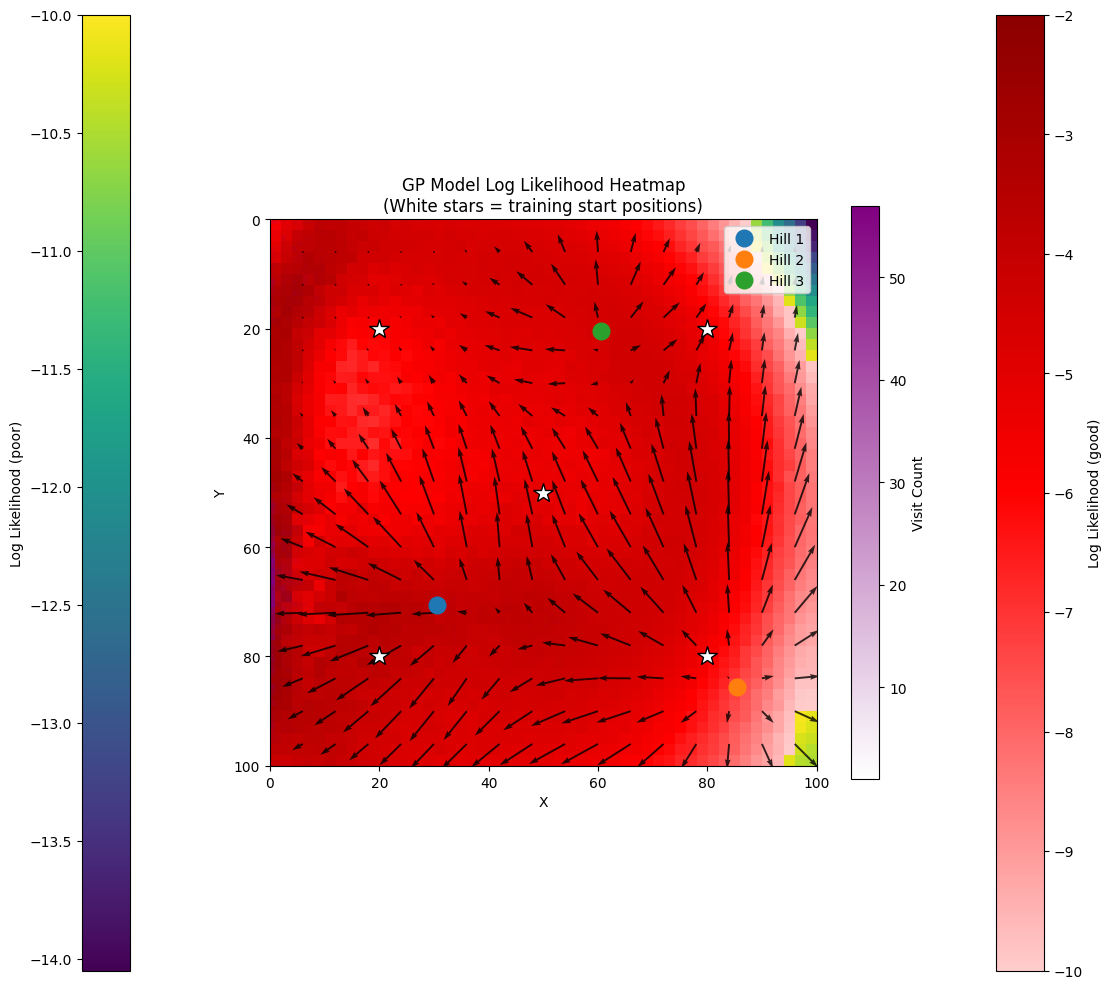

In [8]:
# Plot LL heatmap with visited states overlay
fig, ax = plt.subplots(figsize=(12, 10))
ax, ll_map = plot_ll_heatmap(model, start_positions, env, actions, ax=ax, grid_resolution=50, n_samples_per_cell=20)
plot_visited_overlay(states_visited, ax, color='purple', min_alpha=0.0, max_alpha=1.0)
plt.tight_layout()
plt.show()

Processed row 10/50
Processed row 20/50
Processed row 30/50
Processed row 40/50
Processed row 50/50

Log likelihood statistics:
  Min: -14.12
  Max: -2.64
  Mean: -5.36


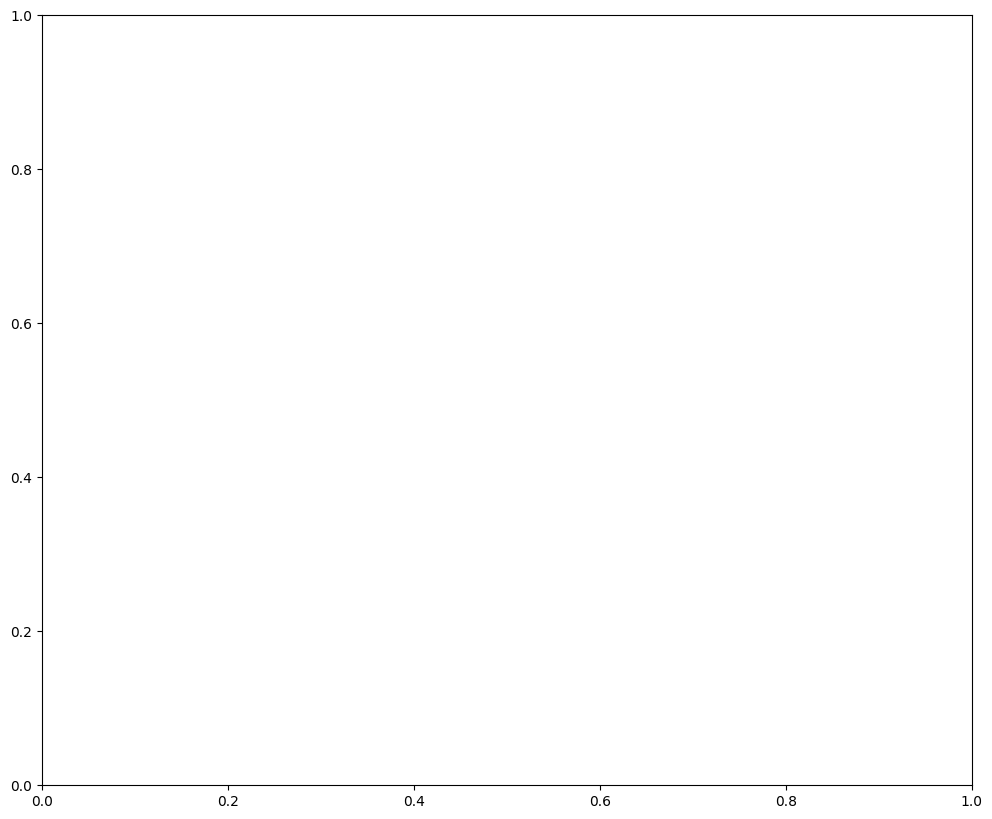

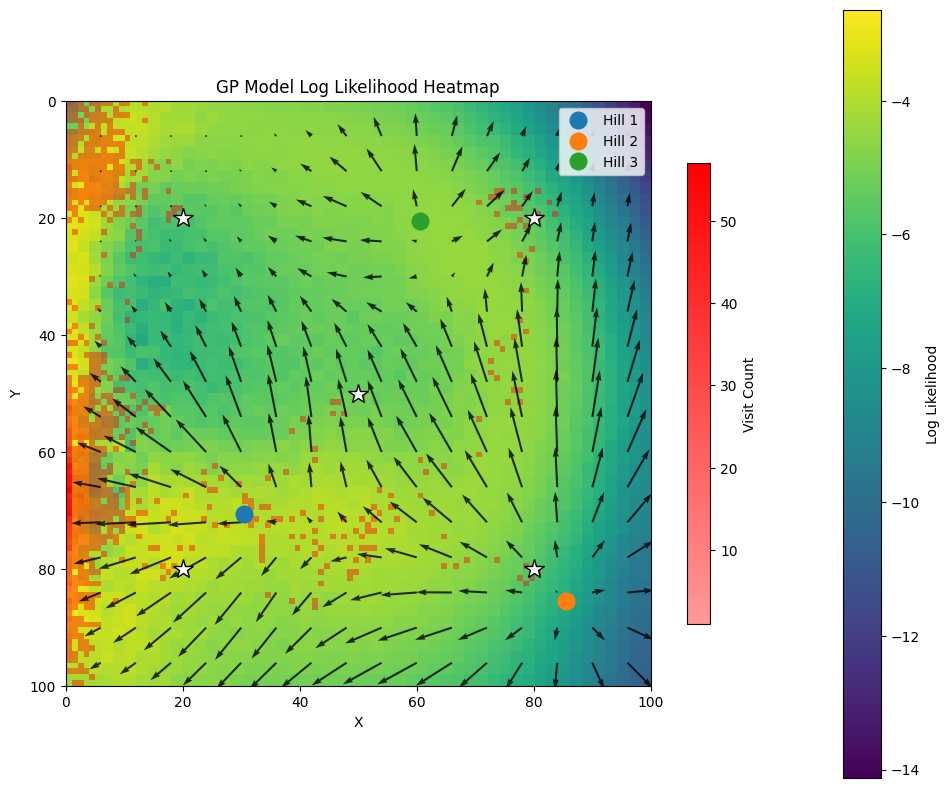

In [10]:
# Example: Simple heatmap with different colormaps
# Common options: 'viridis', 'plasma', 'RdYlGn', 'coolwarm', 'RdBu_r', 'Spectral'
fig, ax = plt.subplots(figsize=(12, 10))
ax, ll_map = plot_ll_heatmap_simple(
    model, start_positions, env, actions,
    grid_resolution=50, 
    n_samples_per_cell=20,
    cmap='viridis'
)
plot_visited_overlay(states_visited, ax, color='red', max_alpha=1.0, min_alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
walk_length = 10
start_positions = [(50, 50), (20, 20), (80, 80), (20, 80), (80, 20)]
actions_taken = [random.choice(list(actions.values())) for _ in range(walk_length*len(start_positions))]
state = start_state


# N samples x M tasks, (0,4) as we have not sampled yet
train_x = torch.empty((0, 4), dtype=torch.float64)
train_y = torch.empty((0, 2), dtype=torch.float64)

states_visited = []

for start_pos in start_positions:
    state = start_pos
    for i in range(walk_length):
        x, y = state
        states_visited.append(state)
        new_state = env.transition(state=state, action=actions_taken[i])
        train_x = torch.cat((train_x, torch.tensor([[x, y, actions_taken[i][0], actions_taken[i][1]]], dtype=torch.float64)), dim=0)
        train_y = torch.cat((train_y, torch.tensor([[new_state[0], new_state[1]]], dtype=torch.float64)), dim=0)
        state = new_state

    

# for i in range(walk_length):
#     x, y = state
#     state = env.transition(state=start_state, action=actions_taken[i])
#     train_x = torch.cat((train_x, torch.tensor([[start_state[0], start_state[1], actions_taken[i][0], actions_taken[i][1]]])), dim=0)
#     train_y = torch.cat((train_y, torch.tensor([[state[0], state[1]]])), dim=0)

print(train_x.shape)
print(train_y.shape)

states_visited = {x: states_visited.count(x) for x in states_visited}
print(f"choises: {actions_taken[:10]}")

torch.Size([2500, 4])
torch.Size([2500, 2])
choises: [(1, 0), (0, -1), (0, 1), (0, 1), (1, 0), (0, 1), (0, -1), (-1, 0), (1, 0), (0, -1)]


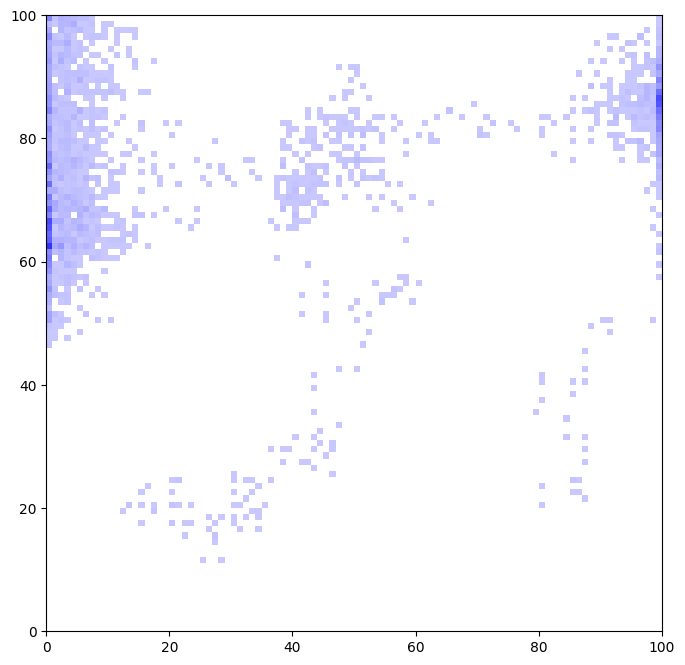

States visited and their counts:
State (50, 50): 1 visits
State (49, 52): 1 visits
State (50, 53): 1 visits
State (45, 56): 1 visits
State (45, 54): 1 visits
State (45, 51): 1 visits
State (45, 50): 1 visits
State (41, 51): 1 visits
State (41, 54): 1 visits
State (42, 59): 2 visits
State (37, 60): 1 visits
State (37, 65): 1 visits
State (36, 66): 1 visits
State (40, 66): 1 visits
State (39, 70): 3 visits
State (39, 69): 1 visits
State (40, 70): 2 visits
State (40, 65): 1 visits
State (40, 67): 3 visits
State (39, 71): 1 visits
State (38, 68): 3 visits
State (37, 70): 1 visits
State (39, 65): 1 visits
State (43, 67): 1 visits
State (43, 70): 1 visits
State (43, 72): 2 visits
State (42, 69): 2 visits
State (42, 66): 1 visits
State (45, 69): 3 visits
State (41, 69): 2 visits
State (43, 71): 1 visits
State (43, 74): 3 visits
State (42, 71): 2 visits
State (41, 72): 1 visits
State (40, 72): 2 visits
State (40, 71): 3 visits
State (40, 68): 1 visits
State (41, 66): 1 visits
State (41, 70): 1

In [43]:
plot_visited_overlay(states_visited, color='blue', max_alpha=0.8, min_alpha=0.2, show_colorbar=False)
plt.show()

print(f"States visited and their counts:")
for state, count in states_visited.items():
    print(f"State {state}: {count} visits")